# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari Kaggle 

  - link dataset sumber= https://www.kaggle.com/code/mohamedelaziz/customer-churn-prediction/input

  - deskripsi = Dataset yang digunakan adalah Telco Customer Churn yang diperoleh dari public repository Kaggle. Dataset ini berisi lebih dari 7.000 baris data pelanggan dengan 21 kolom fitur yang mencakup informasi layanan, informasi tagihan akun, dan data demografis. Target prediksinya adalah kolom Churn, yang menentukan apakah pelanggan tersebut berhenti berlangganan atau tidak.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# Set style untuk visualisasi grafik
sns.set_theme(style="whitegrid")
print("Library berhasil diimpor.")

Library berhasil diimpor.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
# Sesuaikan nama file dengan yang Anda upload
df = pd.read_csv('../WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Menampilkan 5 baris pertama untuk memastikan data masuk
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Informasi Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 

C:\Users\angga\AppData\Local\Temp\ipykernel_37396\2497589147.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


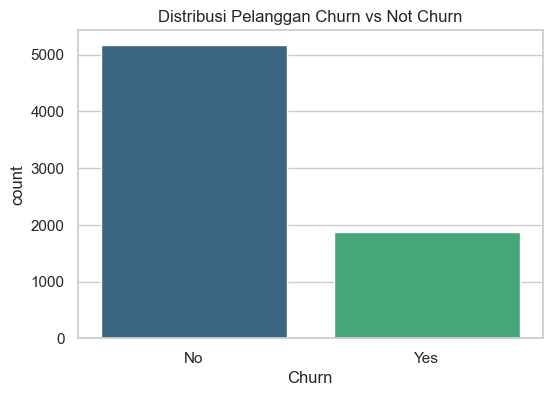

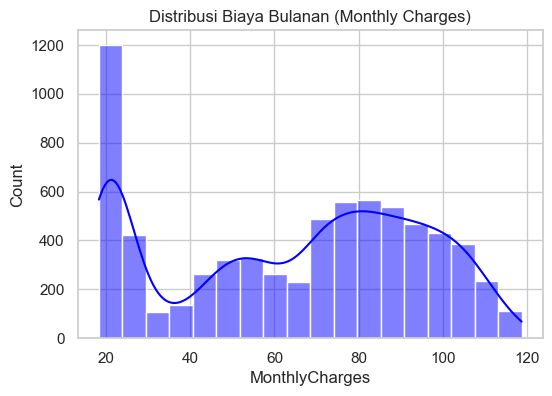

In [4]:
# Mengecek struktur dan tipe data mentah
print("Informasi Dataset:")
df.info()

# Visualisasi distribusi target (Churn)
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribusi Pelanggan Churn vs Not Churn')
plt.show()

# Visualisasi distribusi data numerik (Monthly Charges)
plt.figure(figsize=(6, 4))
sns.histplot(df['MonthlyCharges'], kde=True, color='blue')
plt.title('Distribusi Biaya Bulanan (Monthly Charges)')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
# 1. Menghapus fitur yang tidak relevan (ID)
if 'customerID' in df.columns:
    df.drop('customerID', axis=1, inplace=True)

# 2. Menangani Missing Values & Memperbaiki Tipe Data
# Kolom TotalCharges memiliki nilai kosong berupa spasi, kita ubah ke numerik
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# 3. Menghapus Data Duplikat (jika ada)
df.drop_duplicates(inplace=True)

# 4. Encoding Data Kategorikal
# Mengubah target Churn menjadi angka (Yes=1, No=0)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})
# Mengubah sisa kolom teks menjadi biner (One-Hot Encoding)
df_clean = pd.get_dummies(df, drop_first=True)

# 5. Normalisasi/Standarisasi Fitur (Scaling)
# Menyamakan rentang angka agar model lebih stabil
scaler = StandardScaler()
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

# Menampilkan hasil akhir
display(df_clean.head())
print(f"\nTotal baris dan kolom siap latih: {df_clean.shape}")

# Menyimpan dataset bersih untuk digunakan di tahap automasi dan pemodelan
df_clean.to_csv('data_siap_latih.csv', index=False)
print("Data bersih berhasil disimpan sebagai 'data_siap_latih.csv'")

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,-1.282728,-1.164135,-0.995686,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,0.062387,-0.262811,-0.175262,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,-1.241967,-0.365914,-0.961142,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,0.510759,-0.750058,-0.196769,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,-1.241967,0.194503,-0.941951,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False



Total baris dan kolom siap latih: (7021, 31)
Data bersih berhasil disimpan sebagai 'data_siap_latih.csv'
